<a href="https://colab.research.google.com/github/vrekala648/Assignemnt/blob/main/Patients_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()

Saving load_dataset_module.py to load_dataset_module (1).py
Saving main.py to main.py
Saving query_module.py to query_module.py
Saving statistics_module.py to statistics_module (1).py
Saving user_interface_module.py to user_interface_module.py


In [6]:
# Install matplotlib
!pip install matplotlib

# Add files to Python path
import sys
sys.path.insert(0, '/content')

# Import all modules
from load_dataset_module import DatasetLoader, PatientRecord
from statistics_module import HealthStatistics
from query_module import PatientQuery
import matplotlib.pyplot as plt

print("✅ All modules loaded successfully!")


✅ All modules loaded successfully!


In [7]:
# Generate 200 sample patients
loader = DatasetLoader()
loader.generate_sample_data(n=200, filepath='patients.csv')

print(f"✅ Dataset loaded!")
print(f"👥 Total Patients  : {loader.count}")
print(f"📁 File saved to   : patients.csv")


✅ Dataset loaded!
👥 Total Patients  : 200
📁 File saved to   : patients.csv


In [8]:
print(f"{'ID':<8} {'Name':<20} {'Age':<5} {'Gender':<8} {'Diagnosis':<20} {'Status'}")
print("="*80)

for r in loader.records[:10]:
    print(f"{r.patient_id:<8} {r.name:<20} {r.age:<5} "
          f"{r.gender:<8} {r.diagnosis:<20} {r.status}")

ID       Name                 Age   Gender   Diagnosis            Status
P0001    Patient 1            50    Other    Gastritis            Admitted
P0002    Patient 2            45    Male     Migraine             Admitted
P0003    Patient 3            27    Male     Arthritis            Critical
P0004    Patient 4            84    Other    Depression           Admitted
P0005    Patient 5            18    Male     Appendicitis         Under Observation
P0006    Patient 6            81    Male     COVID-19             Critical
P0007    Patient 7            58    Male     Pneumonia            Admitted
P0008    Patient 8            6     Female   Appendicitis         Stable
P0009    Patient 9            33    Female   Diabetes Type 2      Under Observation
P0010    Patient 10           11    Other    Asthma               Discharged


In [9]:
stats = HealthStatistics(loader)

for field in ('age', 'heart_rate', 'blood_pressure_sys',
              'blood_pressure_dia', 'temperature'):
    s = stats.field_summary(field)
    print(f"\n{'='*45}")
    print(f"  📊 {field.upper()}")
    print(f"{'='*45}")
    print(f"  Count      : {s['count']}")
    print(f"  Mean       : {s['mean']}")
    print(f"  Median     : {s['median']}")
    print(f"  Mode       : {s['mode']}")
    print(f"  Std Dev    : {s['std_dev']}")
    print(f"  Min        : {s['min']}")
    print(f"  Max        : {s['max']}")
    print(f"  Q1         : {s['q1']}")
    print(f"  Q3         : {s['q3']}")
    print(f"  IQR        : {s['iqr']}")


  📊 AGE
  Count      : 200
  Mean       : 45.98
  Median     : 45.0
  Mode       : 50
  Std Dev    : 24.95
  Min        : 5
  Max        : 90
  Q1         : 25.0
  Q3         : 68.0
  IQR        : 43.0

  📊 HEART_RATE
  Count      : 200
  Mean       : 86.7
  Median     : 85.5
  Mode       : 74.0
  Std Dev    : 18.03
  Min        : 56.0
  Max        : 120.0
  Q1         : 71.0
  Q3         : 102.25
  IQR        : 31.25

  📊 BLOOD_PRESSURE_SYS
  Count      : 200
  Mean       : 134.75
  Median     : 133.5
  Mode       : 166.0
  Std Dev    : 27.23
  Min        : 90.0
  Max        : 180.0
  Q1         : 113.0
  Q3         : 158.0
  IQR        : 45.0

  📊 BLOOD_PRESSURE_DIA
  Count      : 200
  Mean       : 85.77
  Median     : 86.0
  Mode       : 86.0
  Std Dev    : 15.02
  Min        : 60.0
  Max        : 110.0
  Q1         : 72.0
  Q3         : 99.0
  IQR        : 27.0

  📊 TEMPERATURE
  Count      : 200
  Mean       : 38.12
  Median     : 38.0
  Mode       : 36.5
  Std Dev    : 1.33
  M

In [11]:
risk = stats.vital_sign_risk_summary()

print("🏥 VITAL SIGNS RISK SUMMARY")
print("="*45)
print(f"  Total Patients     : {risk['total_patients']}")
print(f"  ❤️  Hypertension    : {risk['hypertension_risk']} ({risk['hypertension_pct']}%)")
print(f"  💉 Hypotension     : {risk['hypotension_risk']} ({risk['hypotension_pct']}%)")
print(f"  ⚡ Tachycardia     : {risk['tachycardia_risk']} ({risk['tachycardia_pct']}%)")
print(f"  🐢 Bradycardia     : {risk['bradycardia_risk']} ({risk['bradycardia_pct']}%)")
print(f"  🌡️  Fever (≥38°C)  : {risk['fever_cases']} ({risk['fever_pct']}%)")
print(f"  🥶 Hypothermia     : {risk['hypothermia_cases']} ({risk['hypothermia_pct']}%)")

🏥 VITAL SIGNS RISK SUMMARY
  Total Patients     : 200
  ❤️  Hypertension    : 135 (67.5%)
  💉 Hypotension     : 0 (0.0%)
  ⚡ Tachycardia     : 55 (27.5%)
  🐢 Bradycardia     : 9 (4.5%)
  🌡️  Fever (≥38°C)  : 102 (51.0%)
  🥶 Hypothermia     : 0 (0.0%)


In [12]:
# ── Query 1: Critical patients ──
critical = PatientQuery.critical_patients(loader)
print(f"⚠️  CRITICAL PATIENTS: {len(critical)} found")
print(f"\n{'ID':<8} {'Name':<20} {'HR':<6} {'BP':<12} {'Temp':<7} {'Status'}")
print("="*65)
for r in critical[:10]:
    print(f"{r.patient_id:<8} {r.name:<20} {r.heart_rate:<6} "
          f"{r.blood_pressure_sys}/{r.blood_pressure_dia:<8} "
          f"{r.temperature:<7} {r.status}")

⚠️  CRITICAL PATIENTS: 105 found

ID       Name                 HR     BP           Temp    Status
P0002    Patient 2            85.0   131.0/109.0    39.6    Admitted
P0004    Patient 4            112.0  171.0/60.0     37.1    Admitted
P0005    Patient 5            74.0   99.0/84.0     40.2    Under Observation
P0006    Patient 6            107.0  119.0/108.0    39.4    Critical
P0010    Patient 10           109.0  96.0/104.0    36.1    Discharged
P0011    Patient 11           57.0   164.0/89.0     40.2    Under Observation
P0012    Patient 12           56.0   171.0/63.0     39.3    Stable
P0013    Patient 13           71.0   174.0/104.0    37.8    Discharged
P0016    Patient 16           103.0  158.0/62.0     40.3    Critical
P0017    Patient 17           76.0   92.0/104.0    36.5    Under Observation


In [13]:
# ── Query 2: Filter by gender + diagnosis + age ──
results = (PatientQuery(loader)
           .by_gender('Female')
           .by_diagnosis('Diabetes')
           .age_between(30, 65)
           .execute())

print(f"🔍 Female Diabetes patients (age 30–65): {len(results)} found\n")
print(f"{'ID':<8} {'Name':<20} {'Age':<5} {'BP':<12} {'HR':<6} {'Temp'}")
print("="*60)
for r in results:
    print(f"{r.patient_id:<8} {r.name:<20} {r.age:<5} "
          f"{r.blood_pressure_sys}/{r.blood_pressure_dia:<8} "
          f"{r.heart_rate:<6} {r.temperature}")

🔍 Female Diabetes patients (age 30–65): 2 found

ID       Name                 Age   BP           HR     Temp
P0009    Patient 9            33    140.0/81.0     69.0   37.3
P0059    Patient 59           35    125.0/72.0     99.0   39.7


In [14]:
# ── Query 3: Fever + Admitted patients ──
results = (PatientQuery(loader)
           .by_status('Admitted')
           .temperature_above(38.0)
           .execute())

print(f"🌡️  Admitted patients with fever: {len(results)} found\n")
for r in results[:10]:
    print(f"  {r.patient_id}  {r.name:<20}  Temp: {r.temperature}°C  Diag: {r.diagnosis}")

🌡️  Admitted patients with fever: 18 found

  P0002  Patient 2             Temp: 39.6°C  Diag: Migraine
  P0007  Patient 7             Temp: 38.1°C  Diag: Pneumonia
  P0022  Patient 22            Temp: 39.4°C  Diag: Fracture
  P0037  Patient 37            Temp: 39.8°C  Diag: Appendicitis
  P0049  Patient 49            Temp: 39.1°C  Diag: Arthritis
  P0050  Patient 50            Temp: 40.4°C  Diag: Asthma
  P0065  Patient 65            Temp: 40.0°C  Diag: Appendicitis
  P0072  Patient 72            Temp: 38.9°C  Diag: COVID-19
  P0075  Patient 75            Temp: 40.0°C  Diag: Migraine
  P0091  Patient 91            Temp: 38.4°C  Diag: Heart Failure


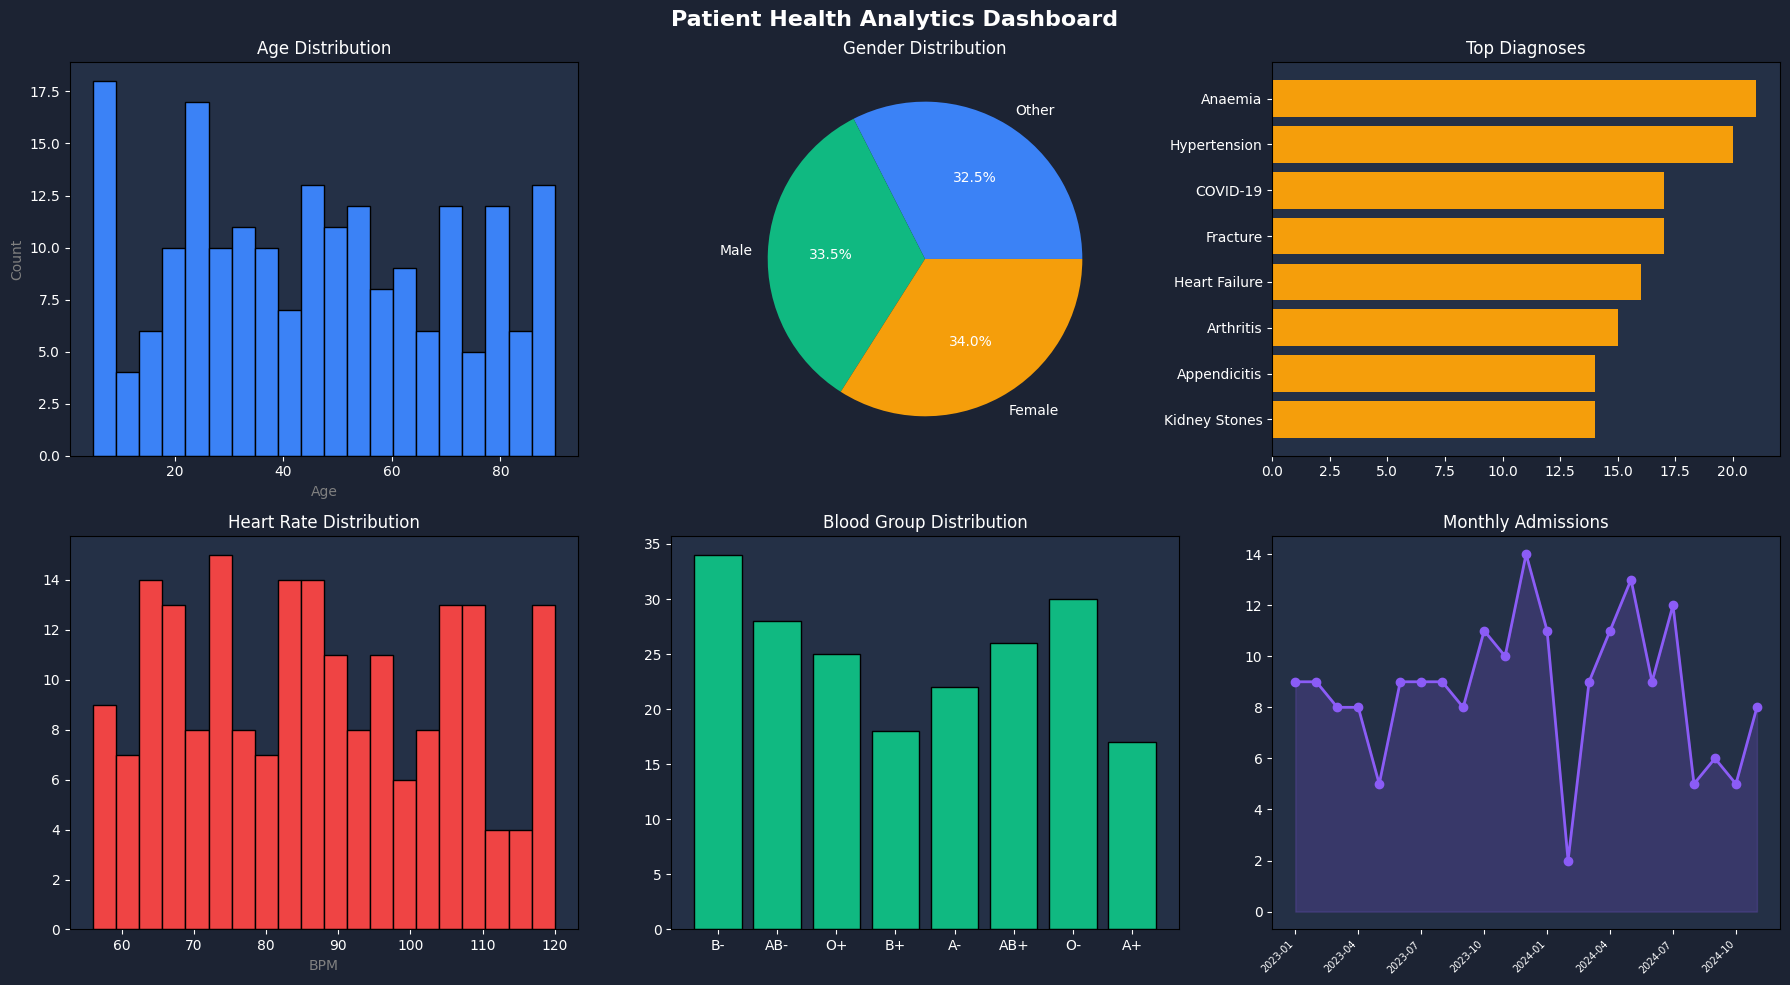

✅ Charts displayed!


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Patient Health Analytics Dashboard',
             fontsize=16, fontweight='bold', color='white')
fig.patch.set_facecolor('#1C2333')

# Chart 1 — Age Distribution
ages = [r.age for r in loader.records]
axes[0,0].hist(ages, bins=20, color='#3B82F6', edgecolor='black')
axes[0,0].set_title('Age Distribution', color='white')
axes[0,0].set_xlabel('Age', color='gray')
axes[0,0].set_ylabel('Count', color='gray')
axes[0,0].set_facecolor('#243046')
axes[0,0].tick_params(colors='white')

# Chart 2 — Gender Pie
gender = stats.gender_distribution()
axes[0,1].pie(gender.values(), labels=gender.keys(),
              autopct='%1.1f%%',
              colors=['#3B82F6','#10B981','#F59E0B'],
              textprops={'color': 'white'})
axes[0,1].set_title('Gender Distribution', color='white')

# Chart 3 — Top Diagnoses
top = stats.top_diagnoses(8)
labels, counts = zip(*top)
axes[0,2].barh(labels, counts, color='#F59E0B')
axes[0,2].set_title('Top Diagnoses', color='white')
axes[0,2].set_facecolor('#243046')
axes[0,2].tick_params(colors='white')
axes[0,2].invert_yaxis()

# Chart 4 — Heart Rate
hr = [r.heart_rate for r in loader.records]
axes[1,0].hist(hr, bins=20, color='#EF4444', edgecolor='black')
axes[1,0].set_title('Heart Rate Distribution', color='white')
axes[1,0].set_xlabel('BPM', color='gray')
axes[1,0].set_facecolor('#243046')
axes[1,0].tick_params(colors='white')

# Chart 5 — Blood Group
bg = stats.blood_group_distribution()
axes[1,1].bar(bg.keys(), bg.values(), color='#10B981', edgecolor='black')
axes[1,1].set_title('Blood Group Distribution', color='white')
axes[1,1].set_facecolor('#243046')
axes[1,1].tick_params(colors='white')

# Chart 6 — Monthly Admissions
monthly = stats.monthly_admissions()
xs = list(monthly.keys())
ys = list(monthly.values())
axes[1,2].plot(xs, ys, color='#8B5CF6', marker='o', linewidth=2)
axes[1,2].fill_between(xs, ys, alpha=0.2, color='#8B5CF6')
axes[1,2].set_title('Monthly Admissions', color='white')
axes[1,2].set_facecolor('#243046')
axes[1,2].tick_params(colors='white')
step = max(1, len(xs)//6)
axes[1,2].set_xticks(range(0, len(xs), step))
axes[1,2].set_xticklabels(xs[::step], rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()
print("✅ Charts displayed!")

In [16]:
from google.colab import files

# Save and download all records
loader.save_csv('final_results.csv')
files.download('final_results.csv')
print("✅ Downloaded final_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded final_results.csv
